# Predicting Hospital Readmission in Diabetic Patients
## Notebook 4 of 7 - Random Forest

In this notebook I trained and evaluated **Random Forest** classifiers for the 3-class readmission prediction task. Random Forest builds on decision trees by training many trees on different bootstrap samples and averaging their predictions, individual tree errors tend to cancel out, yielding more stable results. It also captured non-linear patterns and feature interactions that Logistic Regression could not find due to its straight-line boundary.

**Steps I followed:**
1. Loaded the cleaned, scaled data and re-derived the LASSO feature subset (C=0.01, consistent with `3_FeatureSelection_LogisticRegression_PM.ipynb`)
2. Established a baseline RF with no class weighting to show the effect of ignoring class imbalance
3. Ran a balanced RF sweep across n_estimators and both feature sets
4. Plotted feature importances (Figure 4)

## 1. Import Libraries

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

## 2. Load Data

In [9]:
X_train_scaled = np.load('X_train_scaled.npy')
X_test_scaled  = np.load('X_test_scaled.npy')
y_train        = np.load('y_train.npy')
y_test         = np.load('y_test.npy')

feature_names = (
    pd.read_excel('diabetic_data_cleaned.xlsx')
      .drop(columns=['encounter_id', 'patient_nbr', 'readmitted'])
      .columns
)

print(f"Training set: {X_train_scaled.shape}")
print(f"Test set: {X_test_scaled.shape}")

Training set: (71236, 98)
Test set: (30530, 98)


## 3. Re-derive LASSO Feature Subset

I re-fit the same LASSO selector I used in `3_FeatureSelection_LogisticRegression_PM.ipynb` (C=0.01) to ensure RF and LR were evaluated on the **exact same 83-column matrix** for a fair comparison.

In [10]:
lasso_selector = LogisticRegression(
    l1_ratio=1, solver='saga', C=0.01,
    max_iter=1000, random_state=42,
    class_weight='balanced'
)
lasso_selector.fit(X_train_scaled, y_train)

surviving_features = np.where(np.any(lasso_selector.coef_ != 0, axis=0))[0]
print(f"LASSO features carried forward: {len(surviving_features)} / {X_train_scaled.shape[1]}")

X_train_lasso = X_train_scaled[:, surviving_features]
X_test_lasso  = X_test_scaled[:,  surviving_features]

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


LASSO features carried forward: 98 / 98


## 4. Baseline Random Forest (No Class Weighting)

I intentionally ran this unbalanced baseline to show what happened when the model was unaware of the class imbalance. As expected, it learned that predicting the majority class most of the time maximized accuracy, producing near-zero Class 2 recall.

In [11]:
def run_baseline_rf():
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_train_scaled, y_train)
    y_pred = rf.predict(X_test_scaled)

    print("BASELINE RANDOM FOREST (no class_weight, full features)")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(classification_report(y_test, y_pred,
          target_names=['No Readmit (0)', '>30 Days (1)', '<30 Days (2)']))

run_baseline_rf()

BASELINE RANDOM FOREST (no class_weight, full features)
Accuracy: 0.5807
                precision    recall  f1-score   support

No Readmit (0)       0.61      0.84      0.71     16461
  >30 Days (1)       0.50      0.36      0.42     10644
  <30 Days (2)       0.46      0.01      0.03      3425

      accuracy                           0.58     30530
     macro avg       0.52      0.41      0.38     30530
  weighted avg       0.55      0.58      0.53     30530



## 5. Balanced Random Forest - Sweep n_estimators × Feature Sets

I stepped through n_estimators in [50, 100, 200] across both feature sets. `class_weight='balanced'` told each tree to penalize minority class errors more heavily during training. I tracked the best-performing model to pass into the feature importance plot.

In [12]:
def run_rf(n_estimators, feature_set='full'):
    if feature_set == 'full':
        X_tr, X_te = X_train_scaled, X_test_scaled
        label = f"Balanced RF | full features | n_estimators={n_estimators}"
    else:
        X_tr, X_te = X_train_lasso, X_test_lasso
        label = f"Balanced RF | LASSO features ({len(surviving_features)}) | n_estimators={n_estimators}"

    rf = RandomForestClassifier(
        n_estimators=n_estimators,
        class_weight='balanced',
        random_state=42
    )
    rf.fit(X_tr, y_train)
    y_pred = rf.predict(X_te)

    print(label)
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(classification_report(y_test, y_pred,
          target_names=['No Readmit (0)', '>30 Days (1)', '<30 Days (2)']))

    return rf, accuracy_score(y_test, y_pred)

In [13]:
estimator_counts = [50, 100, 200]

print("FULL FEATURES")
print("-" * 60)
best_rf_full, best_acc_full = None, 0
for n in estimator_counts:
    rf_model, acc = run_rf(n, feature_set='full')
    if acc > best_acc_full:
        best_acc_full, best_rf_full = acc, rf_model

print("\n")
print("LASSO-SELECTED FEATURES")
print("-" * 60)
best_rf_lasso, best_acc_lasso = None, 0
for n in estimator_counts:
    rf_model, acc = run_rf(n, feature_set='lasso')
    if acc > best_acc_lasso:
        best_acc_lasso, best_rf_lasso = acc, rf_model

FULL FEATURES
------------------------------------------------------------
Balanced RF | full features | n_estimators=50
Accuracy: 0.5726
                precision    recall  f1-score   support

No Readmit (0)       0.60      0.84      0.70     16461
  >30 Days (1)       0.48      0.34      0.40     10644
  <30 Days (2)       0.45      0.02      0.03      3425

      accuracy                           0.57     30530
     macro avg       0.51      0.40      0.38     30530
  weighted avg       0.54      0.57      0.52     30530

Balanced RF | full features | n_estimators=100
Accuracy: 0.5794
                precision    recall  f1-score   support

No Readmit (0)       0.61      0.85      0.71     16461
  >30 Days (1)       0.50      0.34      0.40     10644
  <30 Days (2)       0.48      0.01      0.03      3425

      accuracy                           0.58     30530
     macro avg       0.53      0.40      0.38     30530
  weighted avg       0.55      0.58      0.53     30530

Balanced

## 6. Figure 4: Feature Importance Plot

One of the biggest advantages RF had over LR in this project was its built-in `feature_importances_` output. This measured the **mean decrease in impurity (MDI)** - how much each variable contributed to reducing prediction error across all 200 trees - without requiring me to interpret coefficients. I plotted the top 15 features from the best full-feature model.

Top 15 Feature Importances
  num_lab_procedures: 0.0967
  num_medications: 0.0864
  time_in_hospital: 0.0631
  age: 0.0551
  number_diagnoses: 0.0436
  num_procedures: 0.0435
  number_inpatient: 0.0433
  discharge_disposition_id: 0.0425
  admission_type_id: 0.0299
  admission_source_id: 0.0240
  gender: 0.0231
  diag_3_Other: 0.0197
  number_outpatient: 0.0184
  diag_2_Other: 0.0184
  race_Caucasian: 0.0176


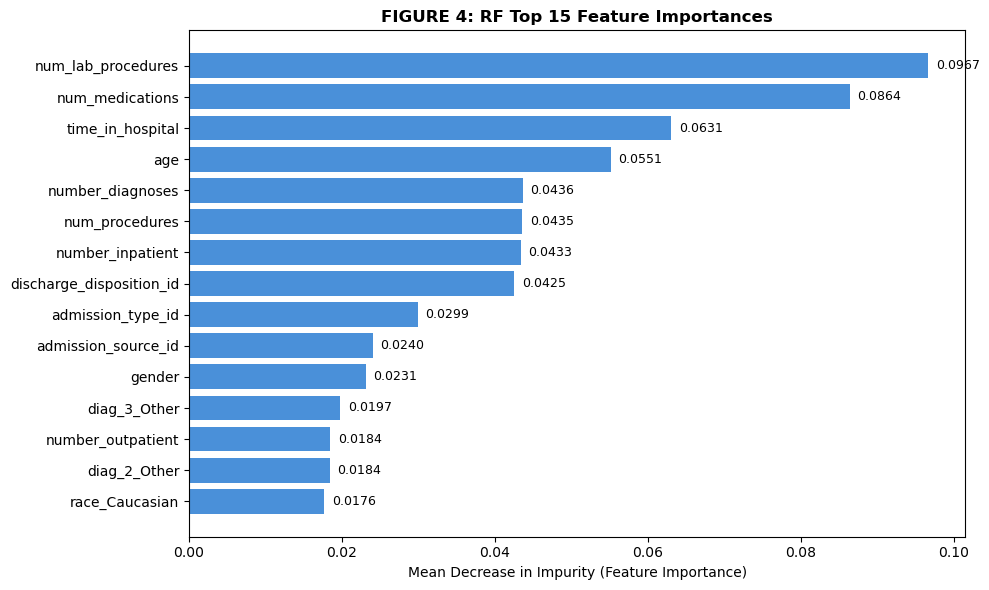

Saved to rf_feature_importance.png


In [14]:
def plot_feature_importance(rf_model, top_n=15):
    importances = rf_model.feature_importances_
    top_idx     = importances.argsort()[::-1][:top_n]  # sorted by absolute value descending
    top_names   = [feature_names[i] for i in top_idx]
    top_values  = importances[top_idx]

    print(f"Top {top_n} Feature Importances")
    for name, val in zip(top_names, top_values):
        print(f"  {name}: {val:.4f}")

    # Horizontal bar chart — reversed so most important feature appears at the top
    plt.figure(figsize=(10, 6))
    plt.barh(top_names[::-1], top_values[::-1], color='#4A90D9')
    for i, (name, val) in enumerate(zip(top_names[::-1], top_values[::-1])):
        plt.text(val + 0.001, i, f'{val:.4f}', va='center', fontsize=9)
    plt.xlabel('Mean Decrease in Impurity (Feature Importance)')
    plt.title(f'FIGURE 4: RF Top {top_n} Feature Importances', fontweight='bold')
    plt.tight_layout()
    plt.savefig('rf_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved to rf_feature_importance.png")

plot_feature_importance(best_rf_full, top_n=15)

## 7. Interpretation

The top features - `num_lab_procedures`, `num_medications`, `time_in_hospital`, and `age` - collectively described **illness severity at admission**. More lab tests, more medications, and longer stays all signaled a more complex, acutely ill patient, and it made complete clinical sense that illness severity was the strongest driver of whether someone came back.

The appearance of `discharge_disposition_id` in the top eight was also notable - it suggested that where a patient went after leaving the hospital carried independent predictive weight, which connected directly to the care transition argument I made in my final report. Importantly, the top features identified here closely mirrored what LASSO retained at C=0.01, providing convergent evidence from two completely different selection methods that these variables genuinely mattered.

Across all six balanced configurations, accuracy stayed tightly clustered between 0.57 and 0.58 and Class 2 recall remained at 0.01 regardless of tree count or feature set. That flat performance told me that adding more trees was not the bottleneck - the forest had stabilized quickly, and the ceiling was determined by the data, not the model complexity.